In [ ]:
import sys
import os
import random
import torch
import numpy as np
import torchvision.transforms as transforms
from matplotlib import pyplot as plt
from PIL import Image
from pathlib import Path
from segment_anything import sam_model_registry

In [3]:
sys.path.append(os.path.abspath(".."))

from sam_lora import SamLoRA
from Util.env_utils import load_segmentation_env, load_as

In [12]:
load_segmentation_env()

SEED = load_as("SEED", int, 42)

MODEL_OUT_DIR = os.getenv("MODEL_OUT_DIR")
MODEL_CHECKPOINTS_DIR = os.getenv("MODEL_CHECKPOINTS_DIR")
DATASETS_DIR = os.getenv("DATASETS_DIR")

DATASET_NAME = os.getenv("DATASET_NAME", "SAM_LoRA_Augmented")
CROPPED_AUG_IMG_DIR_NAME = os.getenv("CROPPED_AUG_IMG_DIR_NAME", "images_256")
CROPPED_AUG_MASK_DIR_NAME = os.getenv("CROPPED_AUG_MASK_DIR_NAME", "masks_256")
LOWRES_IMG_DIR_NAME = os.getenv("LOWRES_IMG_DIR_NAME", "images_1024")

SAM_LORA_MODEL_TYPE = os.getenv("SAM_LORA_MODEL_TYPE", "vit_b")
SAM_LORA_MODEL_CHECKPOINT = os.getenv(
    "SAM_LORA_MODEL_CHECKPOINT", "sam_vit_b_01ec64")
SAM_LORA_RANK = load_as("SAM_LORA_RANK", int, 4)

if MODEL_OUT_DIR is None or MODEL_CHECKPOINTS_DIR is None or DATASETS_DIR is None:
    raise ValueError(
        "MODEL_OUT_DIR, MODEL_CHECKPOINTS_DIR, or DATASETS_DIR environment variable not set.")

loaded environment variables from: /local/scratch/jhehli/ForkSight/Segmentation/.env


In [5]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [6]:
print("cuda available: ", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cuda available:  True


In [32]:
# directory name of the finetuned model
model_name = "sam_lora_finetuning_20251210_155512"
# final (params at last epoch) or minloss (params at epoch with lowest validation loss)
model_checkpoint = "minloss"

model_params_path = Path(MODEL_OUT_DIR) / model_name / \
    f"params_{model_checkpoint}.pt"

params = torch.load(str(model_params_path))

print(f"Loaded {len(params)} named parameters and {sum(p.numel() for p in params.values())} total parameters from finetuned model")
for name, param in params.items():
    print(f"\n--- {name} --- ")
    print(f"shape: {param.shape}")
    print(
        f"max: {param.max().item()}, min: {param.min().item()}, std: {param.std().item()}")

Loaded 44 named parameters and 29772 total parameters from finetuned model

--- sam_model.prompt_encoder.point_embeddings.0.weight --- 
shape: torch.Size([1, 256])
max: 0.617519736289978, min: -0.9075919389724731, std: 0.17018455266952515

--- sam_model.prompt_encoder.point_embeddings.1.weight --- 
shape: torch.Size([1, 256])
max: 0.4669261872768402, min: -0.38336455821990967, std: 0.10633963346481323

--- sam_model.prompt_encoder.point_embeddings.2.weight --- 
shape: torch.Size([1, 256])
max: 0.7160524725914001, min: -0.5038485527038574, std: 0.16412076354026794

--- sam_model.prompt_encoder.point_embeddings.3.weight --- 
shape: torch.Size([1, 256])
max: 0.5915027260780334, min: -0.5512081980705261, std: 0.1708390861749649

--- sam_model.prompt_encoder.not_a_point_embed.weight --- 
shape: torch.Size([1, 256])
max: 0.7708763480186462, min: -0.8103949427604675, std: 0.21169598400592804

--- sam_model.prompt_encoder.mask_downscaling.0.weight --- 
shape: torch.Size([4, 1, 2, 2])
max: 0.02

In [33]:
FINETUNE_IMAGE_ENCODER = False
FINETUNE_MASK_DECODER = True
FINETUNE_PROMPT_ENCODER = True

sam_checkpoint = str(Path(MODEL_CHECKPOINTS_DIR) /
                     f"{SAM_LORA_MODEL_CHECKPOINT}.pth")
model_type = SAM_LORA_MODEL_TYPE
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)

sam_lora = SamLoRA(sam, r=SAM_LORA_RANK, finetune_img_encoder=FINETUNE_IMAGE_ENCODER,
                   finetune_mask_decoder=FINETUNE_MASK_DECODER, finetune_prompt_encoder=FINETUNE_PROMPT_ENCODER)
sam_lora.to(device)

sam_lora.load_state_dict(params, strict=False)

sam_lora.eval()
print()

In [34]:
def load_transform_image(path: Path, resize=(1024, 1024)):
    transform = transforms.Compose([transforms.Resize(resize, interpolation=transforms.InterpolationMode.BILINEAR),
                                    transforms.ToTensor(),
                                    transforms.Lambda(lambda t: t.repeat(3, 1, 1) if t.shape[0] == 1 else t)])

    img = Image.open(path)
    print(f"{path.name}, with size before transform: {img.size}")
    return transform(img)


def show_mask(mask, ax):
    color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def get_batched_input_list(image: torch.Tensor):
    return [{
        "image": img,
        "original_size": (img.shape[1], img.shape[2])
    } for img in image.unsqueeze(0).unbind(0)]


def evaluate_on_image(image_path: Path, figsize=(10, 10)):
    input_img = load_transform_image(image_path).to(device)

    input_list = get_batched_input_list(input_img)

    outputs = sam_lora(batched_input=input_list, multimask_output=False)
    mask = outputs[0]['masks'].squeeze(0).cpu().numpy()

    plt.figure(figsize=figsize)
    plt.imshow(input_img.permute(1, 2, 0).cpu().numpy())
    show_mask(mask, plt.gca())
    plt.axis('off')
    plt.show()

    return mask

20250811_dani_vegetariana_tileset_2_tile_005_009_vflip_patch_8.png, with size before transform: (256, 256)


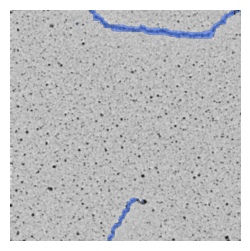

20250811_dani_vegetariana_tileset_2_tile_005_009_gaussiannoise_patch_4.png, with size before transform: (256, 256)


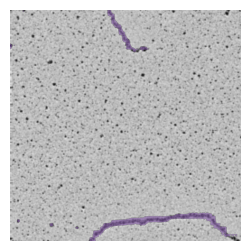

20250811_dani_vegetariana_tileset_2_tile_005_009_patch_0.png, with size before transform: (256, 256)


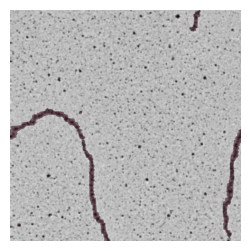

20250811_dani_vegetariana_tileset_2_tile_005_009_randomcrop2_patch_8.png, with size before transform: (256, 256)


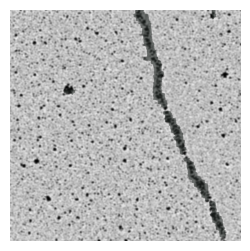

20250811_dani_vegetariana_tileset_2_tile_005_009_rot180_patch_3.png, with size before transform: (256, 256)


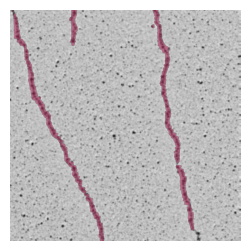

20250811_dani_vegetariana_tileset_2_tile_005_009_griddistort_patch_0.png, with size before transform: (256, 256)


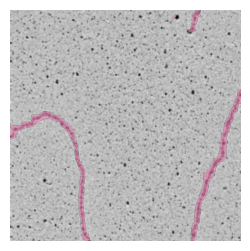

20250811_dani_vegetariana_tileset_2_tile_005_009_randomcrop3_patch_3.png, with size before transform: (256, 256)


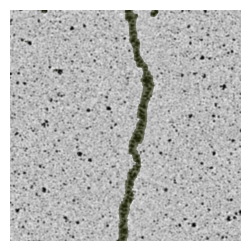

20250811_dani_vegetariana_tileset_2_tile_005_009_vflip_patch_13.png, with size before transform: (256, 256)


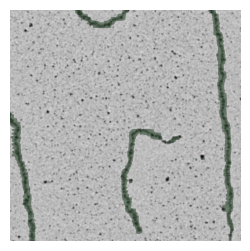

20250811_dani_vegetariana_tileset_2_tile_005_009_griddistort_patch_1.png, with size before transform: (256, 256)


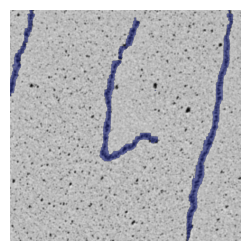

20250811_dani_vegetariana_tileset_2_tile_005_009_hflip_patch_11.png, with size before transform: (256, 256)


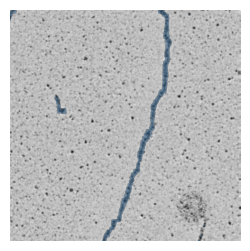

In [35]:
test_img_dir = Path(DATASETS_DIR) / DATASET_NAME / \
    "test" / CROPPED_AUG_IMG_DIR_NAME

for img_path in random.sample(list(test_img_dir.glob("*.png")), 10):
    evaluate_on_image(img_path, figsize=(3, 3))

20250811_dani_vegetariana_tileset_2_tile_005_009_randomcrop4.png, with size before transform: (1024, 1024)


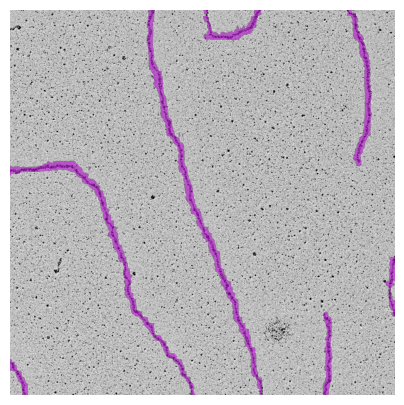

20250811_dani_vegetariana_tileset_2_tile_005_009_randomcrop1.png, with size before transform: (1024, 1024)


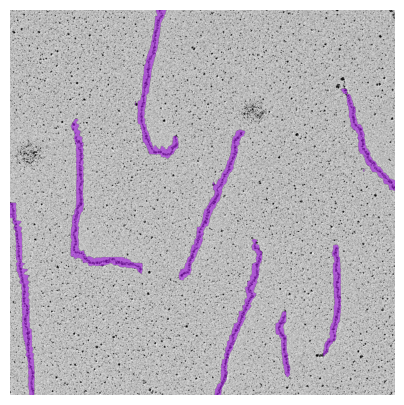

20250811_dani_vegetariana_tileset_2_tile_005_009_rot180.png, with size before transform: (1024, 1024)


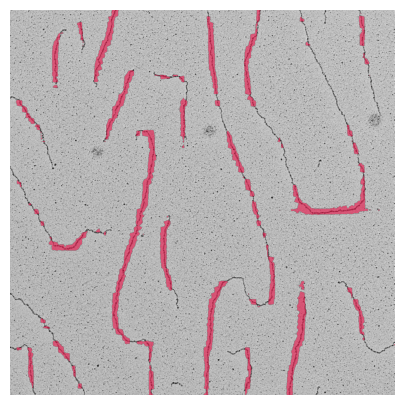

20250811_dani_vegetariana_tileset_2_tile_005_009_randomcrop3.png, with size before transform: (1024, 1024)


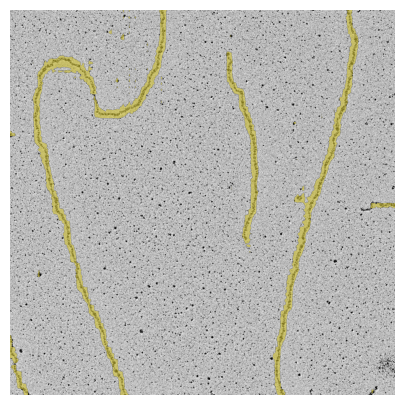

20250811_dani_vegetariana_tileset_2_tile_005_009_griddistort.png, with size before transform: (1024, 1024)


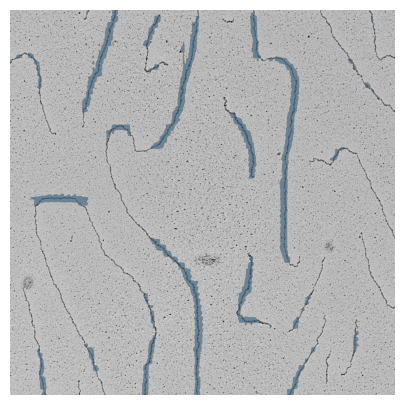

In [36]:
test_img_dir = Path(DATASETS_DIR) / DATASET_NAME / \
    "test" / LOWRES_IMG_DIR_NAME
random_test_images = random.sample(list(test_img_dir.glob("*.png")), 5)

for img_path in random_test_images:
    evaluate_on_image(img_path, figsize=(5, 5))

20240425_andrea_lila_soi_2_bottom.png, with size before transform: (4096, 4096)


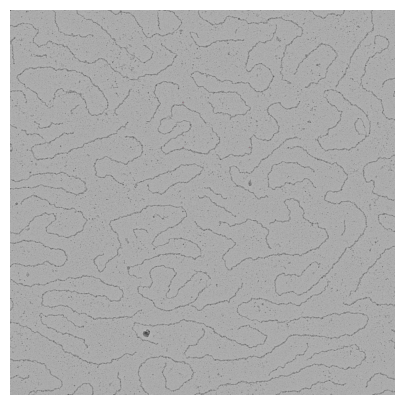

In [37]:
additional_test_img_path = Path("/data/jhehli/additional_data/20240425_andrea_lila_soi_2_bottom.png")
if additional_test_img_path.exists():
    evaluate_on_image(additional_test_img_path, figsize=(5, 5))

20240425_andrea_lila_soi_2_bottom_patch_3.png, with size before transform: (256, 256)


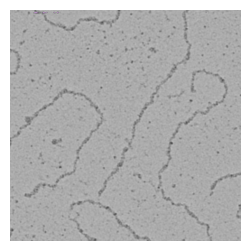

20240425_andrea_lila_soi_2_bottom_patch_10.png, with size before transform: (256, 256)


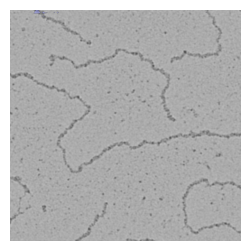

20240425_andrea_lila_soi_2_bottom_patch_8.png, with size before transform: (256, 256)


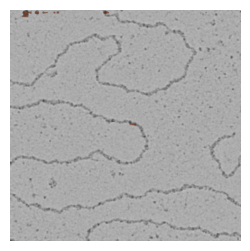

20240425_andrea_lila_soi_2_bottom_patch_12.png, with size before transform: (256, 256)


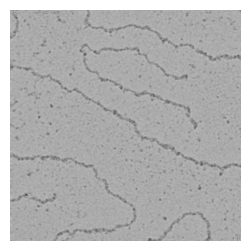

20240425_andrea_lila_soi_2_bottom_patch_4.png, with size before transform: (256, 256)


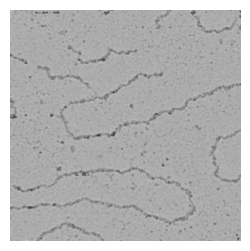

20240425_andrea_lila_soi_2_bottom_patch_14.png, with size before transform: (256, 256)


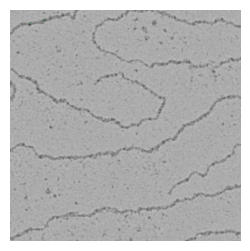

20240425_andrea_lila_soi_2_bottom_patch_5.png, with size before transform: (256, 256)


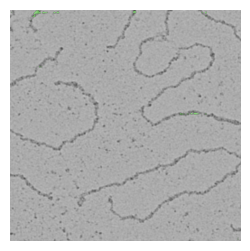

20240425_andrea_lila_soi_2_bottom_patch_1.png, with size before transform: (256, 256)


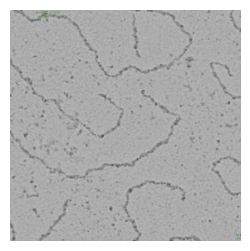

20240425_andrea_lila_soi_2_bottom_patch_11.png, with size before transform: (256, 256)


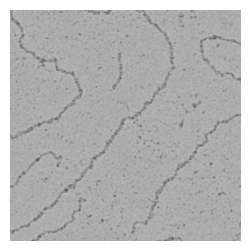

20240425_andrea_lila_soi_2_bottom_patch_15.png, with size before transform: (256, 256)


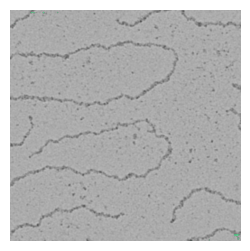

In [31]:
additional_test_cropped_imgs_dir = Path("/data/jhehli/additional_data/lowres_images")
if additional_test_img_path.exists():
    for img_path in random.sample(list(additional_test_cropped_imgs_dir.glob("*.png")), 10):
        evaluate_on_image(img_path, figsize=(3, 3))